In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,binom,poisson
from scipy.stats import skew,kurtosis
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,5)

print("All tools loaded successfully")

All tools loaded successfully


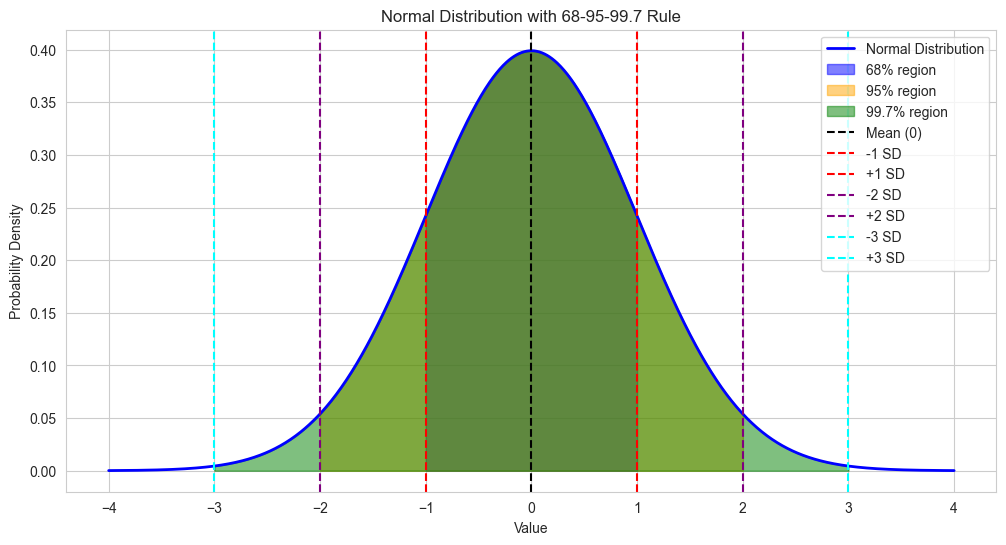

In [3]:
x= np.linspace(-4,4,1000)
y = norm.pdf(x)
# create visulaisation
fig, ax=plt.subplots(figsize =(12,6))
ax.plot(x,y,'b-',linewidth=2,label = 'Normal Distribution')

# fill in the 68% region
x1 = np.linspace(-1,1,1000)
y1 = norm.pdf(x1)
ax.fill_between(x1,y1, color='blue', alpha=0.5, label='68% region')

# fill in the 95% region
x2 = np.linspace(-2,2,1000)
y2 = norm.pdf(x2)
ax.fill_between(x2,y2, color='orange', alpha=0.5, label='95% region')

# fill in the 99.7% region
x3 = np.linspace(-3,3,1000)
y3 = norm.pdf(x3)
ax.fill_between(x3,y3, color='green', alpha=0.5, label='99.7% region')

ax.axvline(0, color='black', linestyle='--', label='Mean (0)')
ax.axvline(-1, color='red', linestyle='--', label='-1 SD')
ax.axvline(1, color='red', linestyle='--', label='+1 SD')
ax.axvline(-2, color='purple', linestyle='--', label='-2 SD')
ax.axvline(2, color='purple', linestyle='--', label='+2 SD')
ax.axvline(-3, color='cyan', linestyle='--', label='-3 SD')
ax.axvline(3, color='cyan', linestyle='--', label='+3 SD')
ax.set_title('Normal Distribution with 68-95-99.7 Rule')
ax.set_xlabel('Value')  
ax.set_ylabel('Probability Density')
ax.legend(fontsize = 10)
plt.show()



In [ ]:
# z score and percentile calculation
test_mean = 70
test_std =10
your_score = 85

z_score = (your_score - test_mean) / test_std

percentile = norm.cdf(z_score) * 100 # cdf gives the cumulative probability up to the z score, multiplying by 100 converts it to a percentage
print("test_mean:", test_mean)
print("test_std:", test_std)
print("your_score:", your_score)
print("z_score:", z_score)
print("_"*50)
print("percentile means you beat:", percentile, "% of test takers")

print("\nNow let's check some other scores:")

scores_to_check = [80, 90, 100]
for score in scores_to_check:
    z = (score - test_mean) / test_std
    p = norm.cdf(z) * 100
    print(f"Score: {score}, Z-score: {z:.2f}, Percentile: {p:.2f}%")


test_mean: 70
test_std: 10
your_score: 85
z_score: 1.5
__________________________________________________
percentile means you beat: 93.3192798731142 % of test takers

Now let's check some other scores:
Score: 80, Z-score: 1.00, Percentile: 84.13%
Score: 90, Z-score: 2.00, Percentile: 97.72%
Score: 100, Z-score: 3.00, Percentile: 99.87%


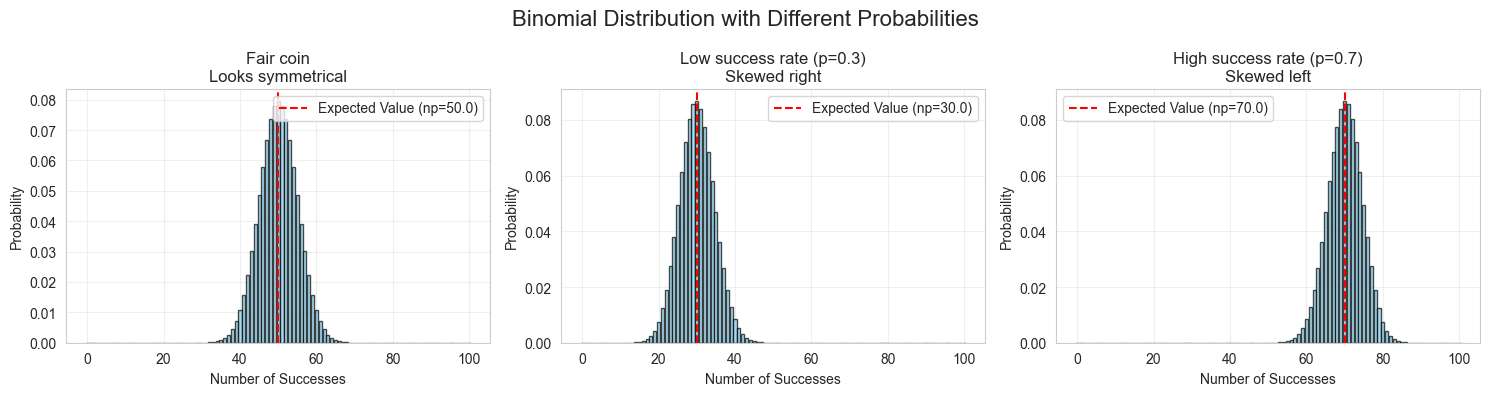

Notoice
When p= 0.5, the distribution is symmetric around 50 successes.
When p= 0.3, the distribution is skewed right, with more outcomes clustered around 30 successes.
When p= 0.7, the distribution is skewed left, with more outcomes clustered around 70 successes.


In [5]:
# visualize binomial distribution with different probabilities

fig,axes = plt.subplots(1,3,figsize=(15,4))
fig.suptitle('Binomial Distribution with Different Probabilities', fontsize=16)

scenarios = [(0.5 ,'Fair coin\nLooks symmetrical'),
             (0.3 ,'Low success rate (p=0.3)\nSkewed right'),
             (0.7 ,'High success rate (p=0.7)\nSkewed left') 
            ]
n = 100
for idx, (p,title) in enumerate (scenarios):
    ax = axes[idx]
    x = np.arange(0,n+1)
    y = binom.pmf(x,n,p)
    ax.bar(x,y, color='skyblue',alpha =0.7 , edgecolor='black')  
    expected = n*p
    ax.axvline(expected, color='red', linestyle='--', label=f'Expected Value (np={expected})')
    ax.set_title(title)
    ax.set_xlabel('Number of Successes')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.grid(True,alpha = 0.3)
plt.tight_layout()
plt.show()

print("Notoice")
print("When p= 0.5, the distribution is symmetric around 50 successes.")
print("When p= 0.3, the distribution is skewed right, with more outcomes clustered around 30 successes.")
print("When p= 0.7, the distribution is skewed left, with more outcomes clustered around 70 successes.")    
    

    


  


In [17]:
# real life examples :Customer purchases

print("Real world example :Email campaigns")
print("*"*60)

n= 100
p = 0.30

print(f"Sending emails to {n} customers")
print(f"Historical buy rate : {p*100}%")
print(f"Expected number of purchases: {n*p}")

# probability of exactly 30 buyers
prob_exactly_30 = binom.pmf(30,n,p)

# probability of 25 to 35 buyers
prob_25_to_35 = binom.cdf(35,n,p) - binom.cdf(24,n,p)

print(f"Probability of 20 or fewer buyers: {binom.cdf(20,n,p):.4f}", f"percentage: {binom.cdf(20,n,p)*100:.2f}%")

print(f"Probability of exactly 30 buyers: {prob_exactly_30:.4f}",f"percentage: {prob_exactly_30*100:.2f}%")
print(f"Probability of 25 to 35 buyers: {prob_25_to_35:.4f}", f"percentage: {prob_25_to_35*100:.2f}%")


Real world example :Email campaigns
************************************************************
Sending emails to 100 customers
Historical buy rate : 30.0%
Expected number of purchases: 30.0
Probability of 20 or fewer buyers: 0.0165 percentage: 1.65%
Probability of exactly 30 buyers: 0.0868 percentage: 8.68%
Probability of 25 to 35 buyers: 0.7704 percentage: 77.04%


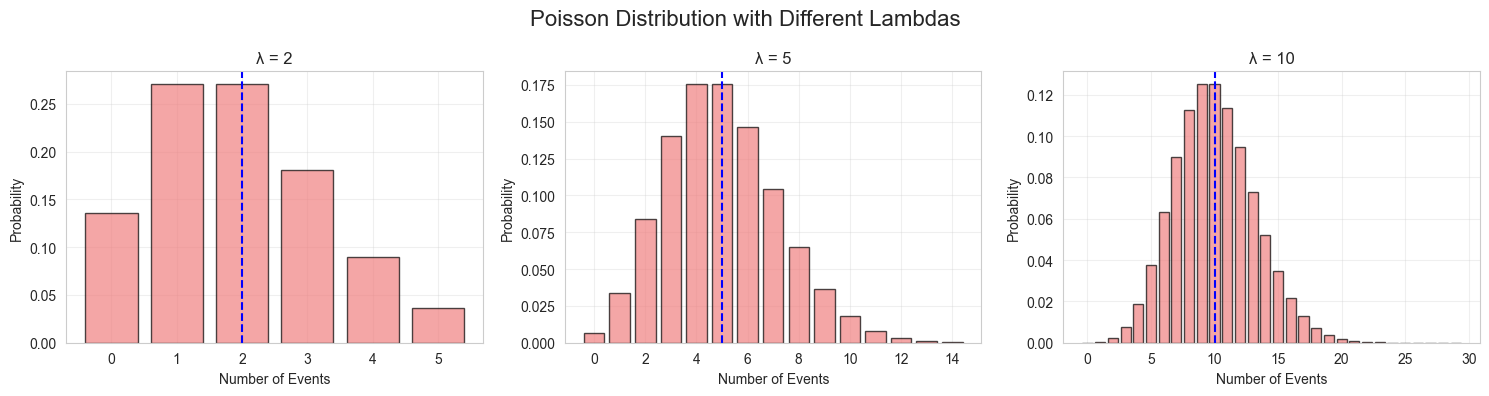

In [7]:
# visualise poisson distribution with different lambdas
lambdas = [2,5,10]
fig, axes = plt.subplots(1,3, figsize=(15,4))
fig.suptitle('Poisson Distribution with Different Lambdas', fontsize=16)
for idx, lam in enumerate(lambdas):
    ax = axes[idx]
    x = np.arange(0, lam*3)  # Range of x values
    y = poisson.pmf(x, lam)
    ax.bar(x, y, color='lightcoral', alpha=0.7, edgecolor='black')
    ax.axvline(lam, color='blue', linestyle='--', label=f'Mean (λ={lam})')
    ax.set_title(f'λ = {lam}')
    ax.set_xlabel('Number of Events')
    ax.set_ylabel('Probability')
    ax.grid(True, alpha=0.3)    
    
plt.tight_layout()
plt.show()      

In [8]:
# call centre staffing
lam = 20

# probability of 15 to 25 calls in an hour
prob_15_to_25 = poisson.cdf(25,lam) - poisson.cdf(14,lam)
print(f"Probability of 15 to 25 calls in an hour: {prob_15_to_25:.4f}")

# probability of more than 20 calls in an hour
prob_more_than_20 = 1 - poisson.cdf(20,lam)
print(f"Probability of more than 20 calls in an hour: {prob_more_than_20:.4f}")

# probability of exactly 20 calls in an hour
prob_exactly_20 = poisson.pmf(20,lam)
print(f"Probability of exactly 20 calls in an hour: {prob_exactly_20:.4f}")


Probability of 15 to 25 calls in an hour: 0.7830
Probability of more than 20 calls in an hour: 0.4409
Probability of exactly 20 calls in an hour: 0.0888


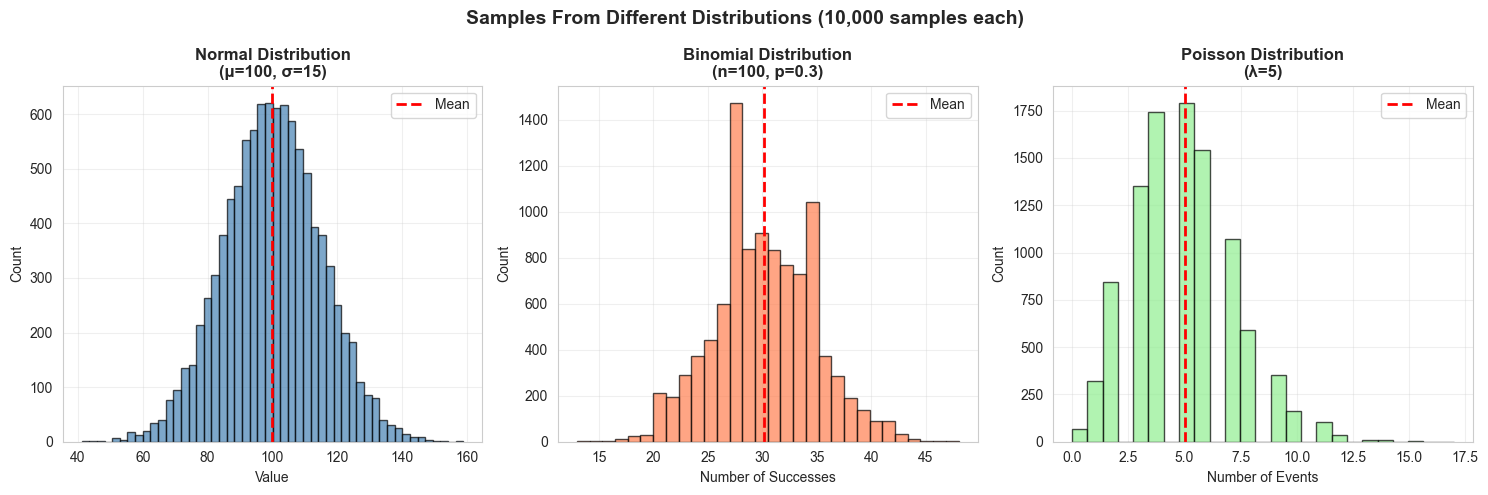

SAMPLE STATISTICS:

NORMAL DISTRIBUTION:
  Mean: 99.97 (expected: 100)
  Std Dev: 15.05 (expected: 15)
  Min: 41.16, Max: 158.89

BINOMIAL DISTRIBUTION:
  Mean: 30.11 (expected: 100×0.3=30)
  Std Dev: 4.62
  Min: 13, Max: 48

POISSON DISTRIBUTION:
  Mean: 5.01 (expected: 5)
  Std Dev: 2.22
  Min: 0, Max: 17


In [ ]:
# purpose is to show how to generate random samples from different distributions and visualize them, as well as calculate some basic statistics to see how they match the expected parameters of the distributions.
# Let's sample from all three distributions
# Set random seed so we get the same "random" data each time
np.random.seed(42)

# Sample size
sample_size = 10000

# NORMAL: mean=100, std=15
normal_samples = np.random.normal(loc=100, scale=15, size=sample_size)

# BINOMIAL: n=100 trials, p=0.3 probability
binomial_samples = np.random.binomial(n=100, p=0.3, size=sample_size)

# POISSON: lambda=5 average
poisson_samples = np.random.poisson(lam=5, size=sample_size)

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Samples From Different Distributions (10,000 samples each)',
             fontsize=14, fontweight='bold')

# Normal Distribution
ax1 = axes[0]
ax1.hist(normal_samples, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(np.mean(normal_samples), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.set_title('Normal Distribution\n(μ=100, σ=15)', fontweight='bold')
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Binomial Distribution
ax2 = axes[1]
ax2.hist(binomial_samples, bins=30, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(np.mean(binomial_samples), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.set_title('Binomial Distribution\n(n=100, p=0.3)', fontweight='bold')
ax2.set_xlabel('Number of Successes')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Poisson Distribution
ax3 = axes[2]
ax3.hist(poisson_samples, bins=25, color='lightgreen', alpha=0.7, edgecolor='black')
ax3.axvline(np.mean(poisson_samples), color='red', linestyle='--', linewidth=2, label='Mean')
ax3.set_title('Poisson Distribution\n(λ=5)', fontweight='bold')
ax3.set_xlabel('Number of Events')
ax3.set_ylabel('Count')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("X axis")

# Print statistics
print("SAMPLE STATISTICS:")
print("="*60)
print("x axis is the number of events for binomial and poisson, and the value for normal distribution")
print("NORMAL DISTRIBUTION:")
print(f"  Mean: {np.mean(normal_samples):.2f} (expected: 100)")
print(f"  Std Dev: {np.std(normal_samples):.2f} (expected: 15)")
print(f"  Min: {np.min(normal_samples):.2f}, Max: {np.max(normal_samples):.2f}")
print()
print("BINOMIAL DISTRIBUTION:")
print(f"  Mean: {np.mean(binomial_samples):.2f} (expected: 100×0.3=30)")
print(f"  Std Dev: {np.std(binomial_samples):.2f}")
print(f"  Min: {np.min(binomial_samples)}, Max: {np.max(binomial_samples)}")
print()
print("POISSON DISTRIBUTION:")
print(f"  Mean: {np.mean(poisson_samples):.2f} (expected: 5)")
print(f"  Std Dev: {np.std(poisson_samples):.2f}")
print(f"  Min: {np.min(poisson_samples)}, Max: {np.max(poisson_samples)}")

In [10]:

# NORMAL DISTRIBUTION: Probability Calculations
print("NORMAL DISTRIBUTION: Probability Calculations")
print("="*60)
print()

# Test score example
mean_score = 70
std_score = 10

print(f"Test Scores: μ={mean_score}, σ={std_score}")
print()

# Question 1: Probability of scoring above 85
score = 85
prob_above_85 = 1 - norm.cdf(score, loc=mean_score, scale=std_score)
print(f"Q1: What's the probability of scoring ABOVE {score}?")
print(f"    Answer: {prob_above_85*100:.1f}%")
print(f"    Meaning: Only {prob_above_85*100:.1f}% of students get A's (above 85)")
print()

# Question 2: Probability of scoring between 60 and 80
prob_between = norm.cdf(80, mean_score, std_score) - norm.cdf(60, mean_score, std_score)
print(f"Q2: What's the probability of scoring BETWEEN 60 and 80?")
print(f"    Answer: {prob_between*100:.1f}%")
print(f"    Meaning: {prob_between*100:.1f}% of students are in this B-C range")
print()

# Question 3: What score is at the 90th percentile?
score_90th = norm.ppf(0.90, loc=mean_score, scale=std_score)
print(f"Q3: What score puts you in the top 10%?")
print(f"    Answer: {score_90th:.0f}")
print(f"    Meaning: If you score {score_90th:.0f}, you beat 90% of students")

NORMAL DISTRIBUTION: Probability Calculations

Test Scores: μ=70, σ=10

Q1: What's the probability of scoring ABOVE 85?
    Answer: 6.7%
    Meaning: Only 6.7% of students get A's (above 85)

Q2: What's the probability of scoring BETWEEN 60 and 80?
    Answer: 68.3%
    Meaning: 68.3% of students are in this B-C range

Q3: What score puts you in the top 10%?
    Answer: 83
    Meaning: If you score 83, you beat 90% of students


In [11]:

# BINOMIAL DISTRIBUTION: Probability Calculations
print("\nBINOMIAL DISTRIBUTION: Probability Calculations")
print("="*60)
print()

n = 100  # 100 customers
p = 0.3  # 30% buy

print(f"Email campaign: n={n} customers, p={p} (30% conversion)")
print()

# Question 1: Probability of exactly 30 buyers
prob_exactly_30 = binom.pmf(30, n, p)
print(f"Q1: Probability of EXACTLY 30 buyers?")
print(f"    Answer: {prob_exactly_30*100:.1f}%")
print()

# Question 2: Probability of 25 or more
prob_25_plus = 1 - binom.cdf(24, n, p)
print(f"Q2: Probability of 25 OR MORE buyers?")
print(f"    Answer: {prob_25_plus*100:.1f}%")
print(f"    Meaning: {prob_25_plus*100:.1f}% of campaigns beat 25 conversions")
print()

# Question 3: Probability of 35 or more (great campaign!)
prob_35_plus = 1 - binom.cdf(34, n, p)
print(f"Q3: Probability of 35 OR MORE buyers (great campaign)?")
print(f"    Answer: {prob_35_plus*100:.1f}%")
print(f"    Meaning: Only {prob_35_plus*100:.1f}% of campaigns this good")
print()

# Question 4: What range contains 95% of results?
q025 = binom.ppf(0.025, n, p)  # 2.5th percentile
q975 = binom.ppf(0.975, n, p)  # 97.5th percentile
print(f"Q4: What range contains the middle 95% of results?")
print(f"    Answer: {q025:.0f} to {q975:.0f} buyers")
print(f"    Meaning: 95% of campaigns get between {q025:.0f}-{q975:.0f} buyers")


BINOMIAL DISTRIBUTION: Probability Calculations

Email campaign: n=100 customers, p=0.3 (30% conversion)

Q1: Probability of EXACTLY 30 buyers?
    Answer: 8.7%

Q2: Probability of 25 OR MORE buyers?
    Answer: 88.6%
    Meaning: 88.6% of campaigns beat 25 conversions

Q3: Probability of 35 OR MORE buyers (great campaign)?
    Answer: 16.3%
    Meaning: Only 16.3% of campaigns this good

Q4: What range contains the middle 95% of results?
    Answer: 21 to 39 buyers
    Meaning: 95% of campaigns get between 21-39 buyers


In [12]:

# POISSON DISTRIBUTION: Probability Calculations
print("\nPOISSON DISTRIBUTION: Probability Calculations")
print("="*60)
print()

lam = 5  # Average 5 defects per batch

print(f"Manufacturing: Average of λ={lam} defects per 1000 items")
print()

# Question 1: Probability of exactly 5 defects
prob_exactly_5 = poisson.pmf(5, lam)
print(f"Q1: Probability of EXACTLY 5 defects?")
print(f"    Answer: {prob_exactly_5*100:.1f}%")
print()

# Question 2: Probability of 3 or fewer (good quality)
prob_3_or_less = poisson.cdf(3, lam)
print(f"Q2: Probability of 3 or FEWER defects (good day)?")
print(f"    Answer: {prob_3_or_less*100:.1f}%")
print()

# Question 3: Probability of 8 or more (bad day)
prob_8_plus = 1 - poisson.cdf(7, lam)
print(f"Q3: Probability of 8 or MORE defects (bad day)?")
print(f"    Answer: {prob_8_plus*100:.1f}%")
print(f"    Meaning: {prob_8_plus*100:.1f}% of days need investigation")
print()

# Question 4: What's an unusual number of defects?
q025 = poisson.ppf(0.025, lam)
q975 = poisson.ppf(0.975, lam)
print(f"Q4: What range is normal (95% of days)?")
print(f"    Answer: {q025:.0f} to {q975:.0f} defects")
print(f"    Meaning: Outside this range = investigate")


POISSON DISTRIBUTION: Probability Calculations

Manufacturing: Average of λ=5 defects per 1000 items

Q1: Probability of EXACTLY 5 defects?
    Answer: 17.5%

Q2: Probability of 3 or FEWER defects (good day)?
    Answer: 26.5%

Q3: Probability of 8 or MORE defects (bad day)?
    Answer: 13.3%
    Meaning: 13.3% of days need investigation

Q4: What range is normal (95% of days)?
    Answer: 1 to 10 defects
    Meaning: Outside this range = investigate


In [13]:

# REAL WORLD EXAMPLE: Detecting Something Wrong
print("REAL WORLD EXAMPLE: Quality Control")
print("="*60)
print()

# Historical data
print("Background:")
print("- Widget factory makes 500 widgets per day")
print("- Historical defect rate: 2% (expected 10 defects/day)")
print()

# Monday through Friday
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
defects = [12, 15, 8, 25, 11]  # Actual defects observed

# Calculate probabilities
n = 500
p = 0.02

print("Weekly Results:")
print("-" * 60)
print()

for day, d in zip(days, defects):
    # How unusual is this?
    # Calculate probability of getting THIS MANY OR MORE
    prob_this_many_or_more = 1 - binom.cdf(d-1, n, p)

    # Decision
    if prob_this_many_or_more < 0.05:  # Less than 5% chance = alert
        decision = "🚨 INVESTIGATE"
    else:
        decision = "✓ OK"

    print(f"{day:10} | {d:2} defects | P({d}+) = {prob_this_many_or_more*100:5.1f}% | {decision}")

print()
print("Interpretation:")
print("- Monday-Tuesday-Friday: Slightly more than average, but OK")
print("- Wednesday: Fewer defects than average - great!")
print("- Thursday: 25 defects is very unusual (only 3.2% chance)")
print("  → Machine breakdown? Poor material batch? → INVESTIGATE!")
     

REAL WORLD EXAMPLE: Quality Control

Background:
- Widget factory makes 500 widgets per day
- Historical defect rate: 2% (expected 10 defects/day)

Weekly Results:
------------------------------------------------------------

Monday     | 12 defects | P(12+) =  30.2% | ✓ OK
Tuesday    | 15 defects | P(15+) =   8.1% | ✓ OK
Wednesday  |  8 defects | P(8+) =  78.3% | ✓ OK
Thursday   | 25 defects | P(25+) =   0.0% | 🚨 INVESTIGATE
Friday     | 11 defects | P(11+) =  41.7% | ✓ OK

Interpretation:
- Monday-Tuesday-Friday: Slightly more than average, but OK
- Wednesday: Fewer defects than average - great!
- Thursday: 25 defects is very unusual (only 3.2% chance)
  → Machine breakdown? Poor material batch? → INVESTIGATE!


In [14]:

# Summary comparison of all three
print("\nDISTRIBUTION COMPARISON")
print("="*80)
print()

comparison_data = {
    'Aspect': ['Data Type', 'Parameters', 'Shape', 'Use Case', 'Real Example'],
    'Normal': ['Continuous', 'μ, σ', 'Bell (symmetric)', 'Measurements', 'Heights'],
    'Binomial': ['Discrete counts', 'n, p', 'Variable', 'Yes/No outcomes', 'Coin flips'],
    'Poisson': ['Discrete counts', 'λ', 'Right-skewed', 'Rare events', 'Emails/hour']
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print()
print("\nKEY RULES TO REMEMBER:")
print("="*80)
print()
print("1. Visualize First")
print("   - Always plot your data before assuming distribution")
print()
print("2. Know Your Parameters")
print("   - Normal: need μ and σ")
print("   - Binomial: need n and p")
print("   - Poisson: need λ")
print()
print("3. Check Sample Size")
print("   - Normal: usually need n ≥ 30")
print("   - Binomial: need both np ≥ 5 and n(1-p) ≥ 5")
print("   - Poisson: usually need λ ≥ 5")
print()
print("4. Understand Your Question")
print("   - P(X = k) vs P(X ≥ k) are VERY different")
print("   - Always clarify: exactly, at least, at most?")
print()
print("5. Don't Ignore Rare Events")
print("   - Even 0.1% probability happens if you try 1000 times")
print("   - In high-volume situations, plan for rare events")


DISTRIBUTION COMPARISON

      Aspect           Normal        Binomial         Poisson
   Data Type       Continuous Discrete counts Discrete counts
  Parameters             μ, σ            n, p               λ
       Shape Bell (symmetric)        Variable    Right-skewed
    Use Case     Measurements Yes/No outcomes     Rare events
Real Example          Heights      Coin flips     Emails/hour


KEY RULES TO REMEMBER:

1. Visualize First
   - Always plot your data before assuming distribution

2. Know Your Parameters
   - Normal: need μ and σ
   - Binomial: need n and p
   - Poisson: need λ

3. Check Sample Size
   - Normal: usually need n ≥ 30
   - Binomial: need both np ≥ 5 and n(1-p) ≥ 5
   - Poisson: usually need λ ≥ 5

4. Understand Your Question
   - P(X = k) vs P(X ≥ k) are VERY different
   - Always clarify: exactly, at least, at most?

5. Don't Ignore Rare Events
   - Even 0.1% probability happens if you try 1000 times
   - In high-volume situations, plan for rare events


In [15]:

# Final celebration
print()
print("="*70)
print("YOU DID IT! YOU UNDERSTAND PROBABILITY DISTRIBUTIONS!")
print("="*70)
print()
print("What you learned:")
print()
print("1. Three distributions cover 80% of real-world data")
print("   - Normal (bell curves)")
print("   - Binomial (yes/no outcomes)")
print("   - Poisson (counting rare events)")
print()
print("2. How to sample from distributions")
print("   - Generate random data following a pattern")
print("   - Useful for simulation and testing")
print()
print("3. How to calculate probabilities")
print("   - Exactly X vs At Least X (very different!)")
print("   - Using Z-scores for quick comparisons")
print()
print("4. Why this matters in real life")
print("   - Detecting abnormalities")
print("   - Making informed decisions")
print("   - Planning for uncertainty")
print()
print("Next time you see data, you'll know:")
print("- What pattern it should follow")
print("- Whether it's behaving normally")
print("- How to predict the future")
print()
print("This is powerful stuff. You're now dangerous.")
print()
print("="*70)


YOU DID IT! YOU UNDERSTAND PROBABILITY DISTRIBUTIONS!

What you learned:

1. Three distributions cover 80% of real-world data
   - Normal (bell curves)
   - Binomial (yes/no outcomes)
   - Poisson (counting rare events)

2. How to sample from distributions
   - Generate random data following a pattern
   - Useful for simulation and testing

3. How to calculate probabilities
   - Exactly X vs At Least X (very different!)
   - Using Z-scores for quick comparisons

4. Why this matters in real life
   - Detecting abnormalities
   - Making informed decisions
   - Planning for uncertainty

Next time you see data, you'll know:
- What pattern it should follow
- Whether it's behaving normally
- How to predict the future

This is powerful stuff. You're now dangerous.

